# 🧠 Digital Behaviour Anomaly Detection in Employee Productivity Patterns
### Open Track — Behavioural Analytics Hackathon

---
**Dataset Type:** Synthetic  
**Why Synthetic:** No real enterprise behavioural dataset is publicly available due to privacy regulations (GDPR, internal NDA policies).  
**Generation Method:** Rule-based simulation with Gaussian distributions, behavioural personas, and injected anomaly events.  
**Records:** 10,000 daily employee activity logs across 200 employees over ~50 working days.  

---
## Problem Statement
Detect anomalous employee digital behaviour that deviates from their own historical baseline — identifying potential insider threats, burnout signals, disengagement, or compromised accounts — using unsupervised and supervised ML approaches.


In [1]:
# ============================================================
# CELL 1: Install & Import Dependencies
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score)
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

# Optional: SHAP for explainability
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not installed. Skipping SHAP explainability section.")

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print("✅ All libraries loaded successfully.")

✅ All libraries loaded successfully.


In [2]:
# ============================================================
# CELL 2: Synthetic Dataset Generation
# ============================================================

def generate_behavioural_dataset(n_employees=200, n_days=50, anomaly_rate=0.08, seed=42):
    """
    Generates synthetic employee digital behaviour logs.

    Behavioural Personas:
    - 'Normal'       : Consistent 9-to-5, low variance, healthy patterns
    - 'Overworker'   : High login hours, weekend work, high email volume
    - 'Disengaged'   : Low login hours, minimal activity, declining trend
    - 'Night Owl'    : Late login times, normal productivity

    Anomaly Types (injected):
    - 'data_exfil'   : Sudden spike in file downloads + off-hours access
    - 'burnout'      : Sudden drop in all activity after prolonged overwork
    - 'account_comp' : Login from unusual hour + unusual app access pattern
    - 'disengagement': Progressive decline in login + task completion
    """
    np.random.seed(seed)
    records = []

    personas = ['normal', 'overworker', 'disengaged', 'night_owl']
    persona_weights = [0.5, 0.2, 0.15, 0.15]

    # Base behavioral profiles per persona
    persona_profiles = {
        'normal':      {'login_hour_mean': 9.0,  'login_hour_std': 0.5,  'hours_worked_mean': 8.0,  'hours_worked_std': 0.7,  'emails_mean': 25,  'files_downloaded_mean': 5,   'apps_accessed_mean': 8},
        'overworker':  {'login_hour_mean': 7.5,  'login_hour_std': 1.0,  'hours_worked_mean': 11.0, 'hours_worked_std': 1.2,  'emails_mean': 55,  'files_downloaded_mean': 12,  'apps_accessed_mean': 14},
        'disengaged':  {'login_hour_mean': 10.0, 'login_hour_std': 1.5,  'hours_worked_mean': 5.5,  'hours_worked_std': 1.5,  'emails_mean': 8,   'files_downloaded_mean': 2,   'apps_accessed_mean': 4},
        'night_owl':   {'login_hour_mean': 14.0, 'login_hour_std': 1.0,  'hours_worked_mean': 8.5,  'hours_worked_std': 0.8,  'emails_mean': 20,  'files_downloaded_mean': 6,   'apps_accessed_mean': 9},
    }

    start_date = datetime(2024, 1, 2)  # Start on a Tuesday
    departments = ['Engineering', 'Sales', 'HR', 'Finance', 'Marketing', 'Operations']

    employee_personas = {}
    employee_depts = {}
    for emp_id in range(n_employees):
        employee_personas[emp_id] = np.random.choice(personas, p=persona_weights)
        employee_depts[emp_id] = np.random.choice(departments)

    anomaly_count = 0
    anomaly_types_list = ['data_exfil', 'burnout', 'account_comp', 'disengagement']

    for day_idx in range(n_days):
        current_date = start_date + timedelta(days=day_idx)
        is_weekend = current_date.weekday() >= 5
        day_of_week = current_date.strftime('%A')

        for emp_id in range(n_employees):
            persona = employee_personas[emp_id]
            profile = persona_profiles[persona]
            dept = employee_depts[emp_id]

            # Skip weekends for most employees (80% skip)
            if is_weekend and np.random.rand() < (0.95 if persona != 'overworker' else 0.5):
                continue

            is_anomaly = 0
            anomaly_type = 'normal'

            # Inject anomalies randomly
            if np.random.rand() < anomaly_rate:
                anomaly_type = np.random.choice(anomaly_types_list)
                is_anomaly = 1
                anomaly_count += 1

                if anomaly_type == 'data_exfil':
                    login_hour = np.random.uniform(0, 5)  # Very early/late
                    hours_worked = np.random.uniform(1, 4)
                    emails_sent = int(np.random.normal(profile['emails_mean'], 2))
                    files_downloaded = int(np.random.uniform(50, 150))  # Massive spike
                    apps_accessed = int(np.random.uniform(20, 35))  # Unusual apps
                    tasks_completed = int(np.random.uniform(0, 2))
                    meeting_hours = 0

                elif anomaly_type == 'burnout':
                    login_hour = np.random.uniform(11, 14)  # Very late login
                    hours_worked = np.random.uniform(1, 3)  # Sudden crash
                    emails_sent = int(np.random.uniform(0, 3))
                    files_downloaded = int(np.random.uniform(0, 2))
                    apps_accessed = int(np.random.uniform(1, 3))
                    tasks_completed = int(np.random.uniform(0, 1))
                    meeting_hours = 0

                elif anomaly_type == 'account_comp':
                    login_hour = np.random.uniform(1, 4)  # Middle of night
                    hours_worked = np.random.uniform(6, 14)
                    emails_sent = int(np.random.normal(profile['emails_mean'] * 3, 5))
                    files_downloaded = int(np.random.uniform(30, 80))
                    apps_accessed = int(np.random.uniform(25, 40))  # Many unusual apps
                    tasks_completed = int(np.random.uniform(0, 3))
                    meeting_hours = 0

                elif anomaly_type == 'disengagement':
                    login_hour = np.random.normal(profile['login_hour_mean'] + 2, 1)
                    hours_worked = max(0.5, np.random.uniform(1, 3))
                    emails_sent = int(np.random.uniform(0, 4))
                    files_downloaded = int(np.random.uniform(0, 2))
                    apps_accessed = int(np.random.uniform(1, 4))
                    tasks_completed = int(np.random.uniform(0, 1))
                    meeting_hours = np.random.uniform(0, 0.5)
            else:
                # Normal behaviour with persona-based distributions
                login_hour = max(0, min(23, np.random.normal(profile['login_hour_mean'], profile['login_hour_std'])))
                hours_worked = max(1, min(16, np.random.normal(profile['hours_worked_mean'], profile['hours_worked_std'])))
                emails_sent = max(0, int(np.random.poisson(profile['emails_mean'])))
                files_downloaded = max(0, int(np.random.poisson(profile['files_downloaded_mean'])))
                apps_accessed = max(1, int(np.random.normal(profile['apps_accessed_mean'], 2)))
                tasks_completed = max(0, int(np.random.poisson(4 if persona != 'disengaged' else 1.5)))
                meeting_hours = max(0, np.random.normal(1.5 if persona == 'normal' else 2.5, 0.5))

            # Derived / engineered features
            logout_hour = min(23.99, login_hour + hours_worked)
            is_off_hours = 1 if (login_hour < 7 or login_hour > 20) else 0
            productivity_ratio = tasks_completed / max(1, hours_worked)
            email_intensity = emails_sent / max(1, hours_worked)
            download_intensity = files_downloaded / max(1, hours_worked)

            records.append({
                'employee_id': f'EMP_{emp_id:04d}',
                'date': current_date.strftime('%Y-%m-%d'),
                'day_of_week': day_of_week,
                'department': dept,
                'persona': persona,
                'login_hour': round(login_hour, 2),
                'logout_hour': round(logout_hour, 2),
                'hours_worked': round(hours_worked, 2),
                'emails_sent': emails_sent,
                'files_downloaded': files_downloaded,
                'apps_accessed': apps_accessed,
                'tasks_completed': tasks_completed,
                'meeting_hours': round(meeting_hours, 2),
                'is_off_hours': is_off_hours,
                'is_weekend': int(is_weekend),
                'productivity_ratio': round(productivity_ratio, 3),
                'email_intensity': round(email_intensity, 3),
                'download_intensity': round(download_intensity, 3),
                'is_anomaly': is_anomaly,
                'anomaly_type': anomaly_type
            })

    df = pd.DataFrame(records)
    print(f"✅ Dataset generated: {len(df):,} records")
    print(f"   Employees: {n_employees} | Days: {n_days}")
    print(f"   Total anomalies injected: {df['is_anomaly'].sum():,} ({df['is_anomaly'].mean()*100:.1f}%)")
    print(f"   Anomaly type distribution:")
    print(df[df['is_anomaly']==1]['anomaly_type'].value_counts().to_string())
    return df

df = generate_behavioural_dataset(n_employees=200, n_days=50, anomaly_rate=0.08)
df.to_csv('/tmp/employee_behaviour_dataset.csv', index=False)
print("\n📁 Dataset saved to employee_behaviour_dataset.csv")
df.head()

✅ Dataset generated: 7,603 records
   Employees: 200 | Days: 50
   Total anomalies injected: 589 (7.7%)
   Anomaly type distribution:
anomaly_type
disengagement    158
data_exfil       152
burnout          140
account_comp     139

📁 Dataset saved to employee_behaviour_dataset.csv


,employee_id,date,day_of_week,department,persona,login_hour,logout_hour,hours_worked,emails_sent,files_downloaded,apps_accessed,tasks_completed,meeting_hours,is_off_hours,is_weekend,productivity_ratio,email_intensity,download_intensity,is_anomaly,anomaly_type
0,EMP_0000,2024-01-02,Tuesday,Marketing,normal,12.47,14.42,1.95,0,0,1,0,0.00,0,0,0.000,0.000,0.000,1,burnout
1,EMP_0001,2024-01-02,Tuesday,Marketing,normal,8.94,16.61,7.67,27,3,7,8,1.53,0,0,1.042,3.518,0.391,0,normal
2,EMP_0002,2024-01-02,Tuesday,Sales,overworker,7.01,18.26,11.25,51,10,15,6,3.23,0,0,0.533,4.534,0.889,0,normal
3,EMP_0003,2024-01-02,Tuesday,HR,normal,8.11,15.25,7.15,29,9,7,0,1.93,0,0,0.000,4.058,1.260,0,normal
4,EMP_0004,2024-01-02,Tuesday,Marketing,normal,8.86,16.44,7.57,26,7,6,4,1.50,0,0,0.528,3.434,0.925,0,normal


In [3]:
# ============================================================
# CELL 3: Exploratory Data Analysis (EDA)
# ============================================================

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nColumn Types:")
print(df.dtypes)
print(f"\nMissing Values: {df.isnull().sum().sum()}")
print(f"\nNumerical Summary:")
df.describe().round(2)

DATASET OVERVIEW
Shape: (7603, 20)

Column Types:
employee_id            object
date                   object
day_of_week            object
department             object
persona                object
login_hour            float64
logout_hour           float64
hours_worked          float64
emails_sent             int64
files_downloaded        int64
apps_accessed           int64
tasks_completed         int64
meeting_hours         float64
is_off_hours            int64
is_weekend              int64
productivity_ratio    float64
email_intensity       float64
download_intensity    float64
is_anomaly              int64
anomaly_type           object
dtype: object

Missing Values: 0

Numerical Summary:


,login_hour,logout_hour,hours_worked,emails_sent,files_downloaded,apps_accessed,tasks_completed,meeting_hours,is_off_hours,is_weekend,productivity_ratio,email_intensity,download_intensity,is_anomaly
count,7603.00,7603.00,7603.00,7603.00,7603.00,7603.00,7603.00,7603.00,7603.00,7603.00,7603.00,7603.00,7603.00,7603.00
mean,9.15,17.39,8.25,30.37,9.17,9.32,3.52,1.83,0.11,0.05,0.42,3.61,1.72,0.08
std,2.48,3.04,2.40,19.65,15.80,5.56,2.21,0.85,0.32,0.22,0.27,2.82,7.08,0.27
min,0.09,1.52,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,8.18,16.29,7.39,19.00,3.00,6.00,2.00,1.30,0.00,0.00,0.24,2.41,0.46,0.00
50%,8.96,17.28,8.24,25.00,6.00,8.00,3.00,1.87,0.00,0.00,0.39,3.20,0.70,0.00
75%,9.66,18.60,9.46,43.00,9.00,12.00,5.00,2.47,0.00,0.00,0.59,4.33,1.00,0.00
max,17.94,23.99,15.25,178.00,149.00,39.00,13.00,4.19,1.00,1.00,2.01,55.03,129.38,1.00


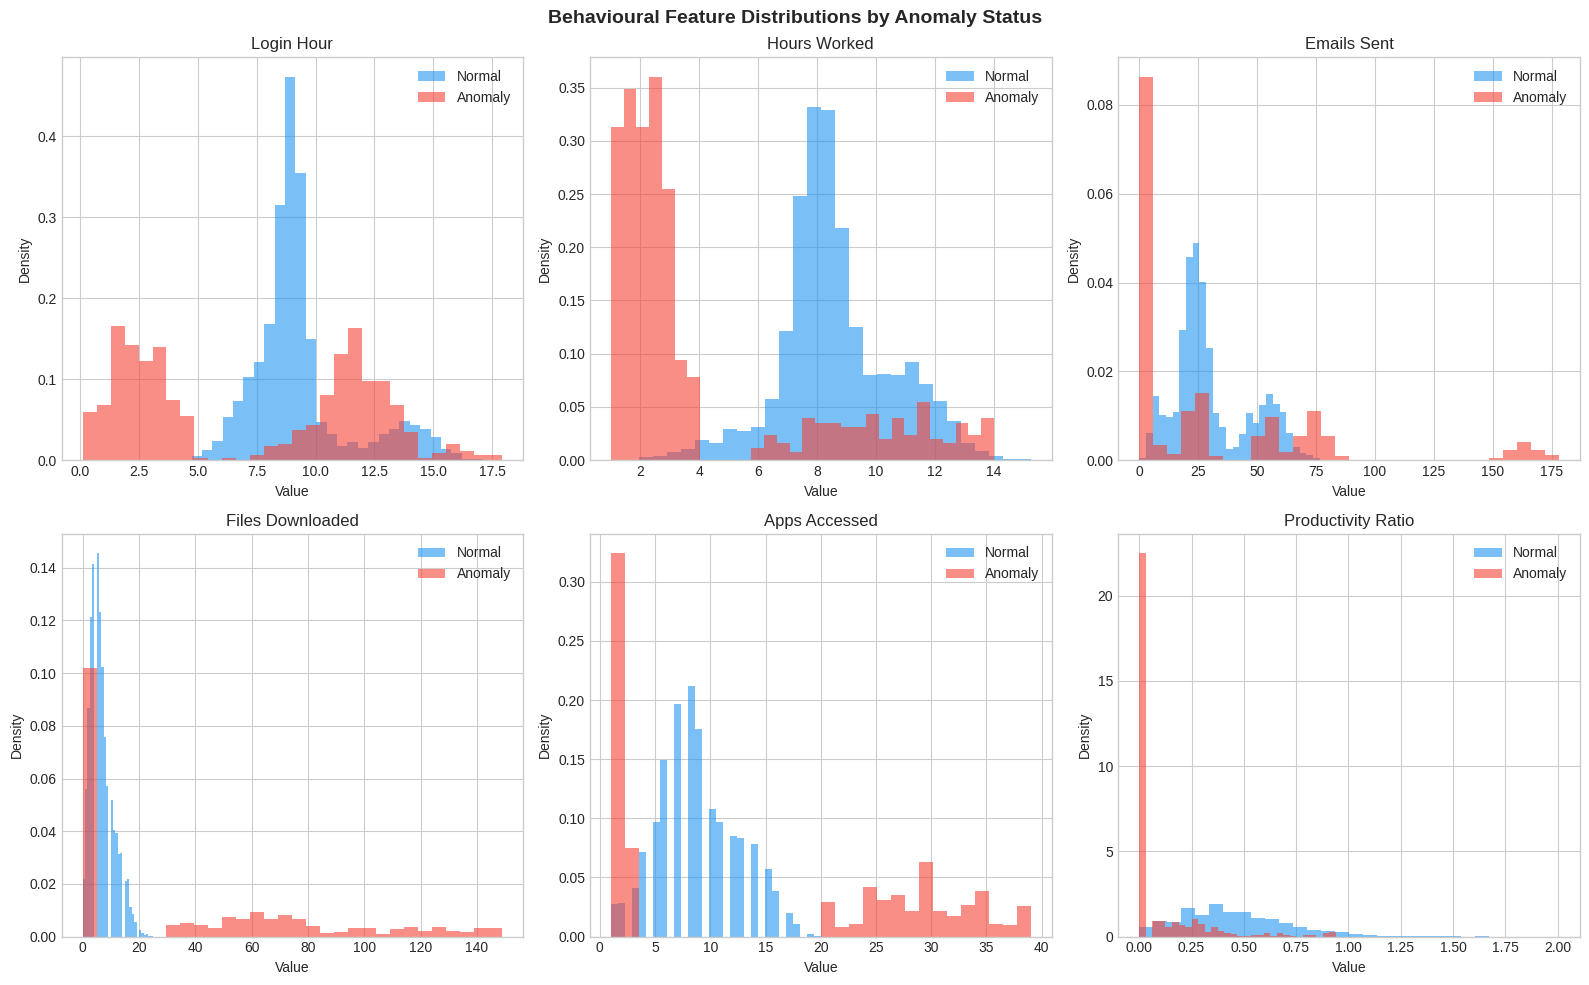

📊 Distribution plots saved.


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Behavioural Feature Distributions by Anomaly Status', fontsize=14, fontweight='bold')

features_to_plot = ['login_hour', 'hours_worked', 'emails_sent',
                    'files_downloaded', 'apps_accessed', 'productivity_ratio']

colors = {0: '#2196F3', 1: '#F44336'}
labels = {0: 'Normal', 1: 'Anomaly'}

for ax, feat in zip(axes.flatten(), features_to_plot):
    for status in [0, 1]:
        subset = df[df['is_anomaly'] == status][feat]
        ax.hist(subset, bins=30, alpha=0.6, color=colors[status],
                label=labels[status], density=True)
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.savefig('/tmp/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Distribution plots saved.")

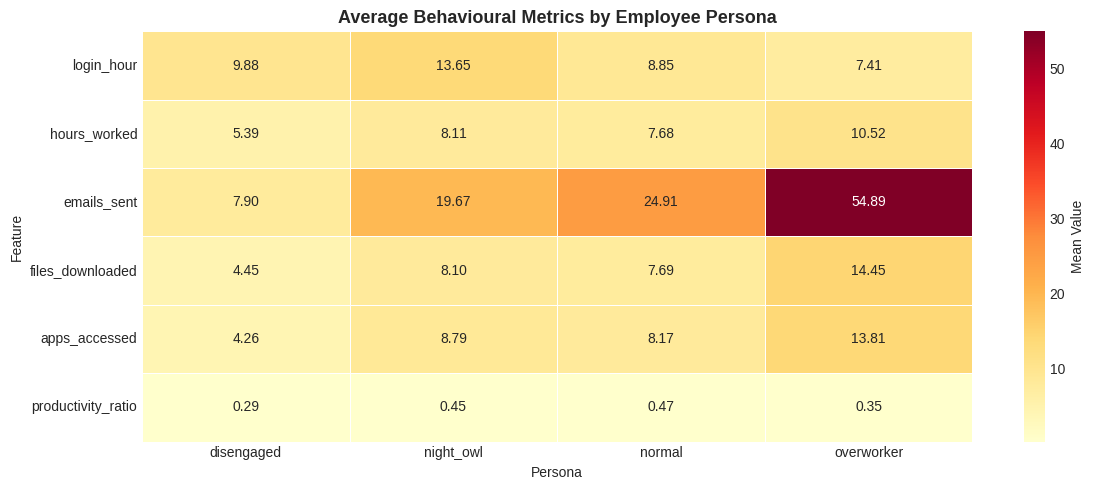

In [5]:
# Persona behaviour heatmap
persona_stats = df.groupby('persona')[features_to_plot].mean()

plt.figure(figsize=(12, 5))
sns.heatmap(persona_stats.T, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Mean Value'})
plt.title('Average Behavioural Metrics by Employee Persona', fontsize=13, fontweight='bold')
plt.ylabel('Feature')
plt.xlabel('Persona')
plt.tight_layout()
plt.savefig('/tmp/persona_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

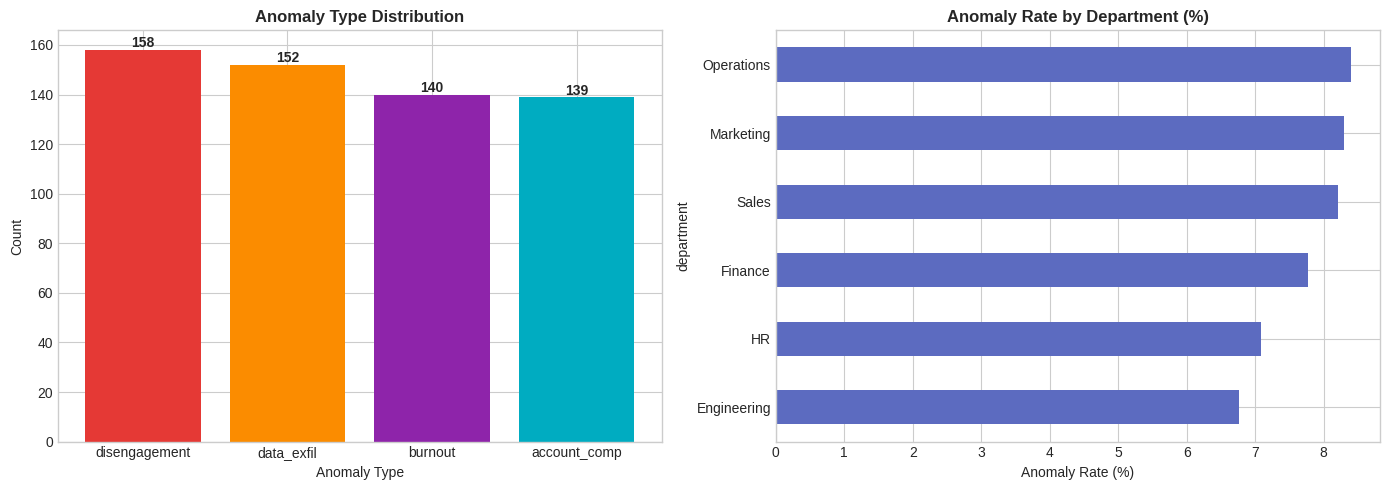

In [6]:
# Anomaly type distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Anomaly type breakdown
anomaly_df = df[df['is_anomaly']==1]
anom_counts = anomaly_df['anomaly_type'].value_counts()
colors_bar = ['#E53935', '#FB8C00', '#8E24AA', '#00ACC1']
ax1.bar(anom_counts.index, anom_counts.values, color=colors_bar)
ax1.set_title('Anomaly Type Distribution', fontweight='bold')
ax1.set_xlabel('Anomaly Type')
ax1.set_ylabel('Count')
for i, v in enumerate(anom_counts.values):
    ax1.text(i, v + 1, str(v), ha='center', fontweight='bold')

# Anomalies by department
dept_anom = df.groupby('department')['is_anomaly'].mean() * 100
dept_anom.sort_values(ascending=True).plot(kind='barh', ax=ax2, color='#5C6BC0')
ax2.set_title('Anomaly Rate by Department (%)', fontweight='bold')
ax2.set_xlabel('Anomaly Rate (%)')

plt.tight_layout()
plt.savefig('/tmp/anomaly_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ============================================================
# CELL 4: Feature Engineering
# ============================================================

print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

df_fe = df.copy()

# --- Z-score per employee (deviation from personal baseline) ---
numeric_feats = ['hours_worked', 'emails_sent', 'files_downloaded',
                 'apps_accessed', 'tasks_completed', 'login_hour']

for feat in numeric_feats:
    emp_mean = df_fe.groupby('employee_id')[feat].transform('mean')
    emp_std = df_fe.groupby('employee_id')[feat].transform('std').replace(0, 1)
    df_fe[f'{feat}_zscore'] = (df_fe[feat] - emp_mean) / emp_std

# --- Rolling 7-day average deviation ---
df_fe = df_fe.sort_values(['employee_id', 'date'])
for feat in ['hours_worked', 'files_downloaded', 'emails_sent']:
    df_fe[f'{feat}_rolling7_mean'] = (
        df_fe.groupby('employee_id')[feat]
        .transform(lambda x: x.rolling(7, min_periods=1).mean())
    )
    df_fe[f'{feat}_deviation_from_rolling'] = df_fe[feat] - df_fe[f'{feat}_rolling7_mean']

# --- Behavioural composite score ---
df_fe['anomaly_score_manual'] = (
    np.abs(df_fe['files_downloaded_zscore']) * 0.35 +
    np.abs(df_fe['login_hour_zscore']) * 0.25 +
    np.abs(df_fe['apps_accessed_zscore']) * 0.20 +
    np.abs(df_fe['hours_worked_zscore']) * 0.10 +
    df_fe['is_off_hours'] * 0.10
)

# --- Day of week encoding ---
dow_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
           'Friday': 4, 'Saturday': 5, 'Sunday': 6}
df_fe['day_of_week_num'] = df_fe['day_of_week'].map(dow_map)

# --- Department encoding ---
le = LabelEncoder()
df_fe['dept_encoded'] = le.fit_transform(df_fe['department'])

new_features = [c for c in df_fe.columns if c not in df.columns]
print(f"\n✅ Engineered {len(new_features)} new features:")
for f in new_features:
    print(f"   - {f}")

FEATURE ENGINEERING

✅ Engineered 15 new features:
   - hours_worked_zscore
   - emails_sent_zscore
   - files_downloaded_zscore
   - apps_accessed_zscore
   - tasks_completed_zscore
   - login_hour_zscore
   - hours_worked_rolling7_mean
   - hours_worked_deviation_from_rolling
   - files_downloaded_rolling7_mean
   - files_downloaded_deviation_from_rolling
   - emails_sent_rolling7_mean
   - emails_sent_deviation_from_rolling
   - anomaly_score_manual
   - day_of_week_num
   - dept_encoded


In [8]:
# ============================================================
# CELL 5: Model 1 — Isolation Forest (Unsupervised)
# ============================================================

print("=" * 60)
print("MODEL 1: ISOLATION FOREST (Unsupervised Anomaly Detection)")
print("=" * 60)

feature_cols = [
    'login_hour', 'hours_worked', 'emails_sent', 'files_downloaded',
    'apps_accessed', 'tasks_completed', 'meeting_hours',
    'is_off_hours', 'is_weekend', 'productivity_ratio',
    'email_intensity', 'download_intensity',
    'hours_worked_zscore', 'files_downloaded_zscore',
    'login_hour_zscore', 'apps_accessed_zscore',
    'anomaly_score_manual', 'day_of_week_num', 'dept_encoded'
]

X = df_fe[feature_cols].fillna(0)
y = df_fe['is_anomaly']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Isolation Forest
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.08,
    max_features=0.8,
    random_state=42
)
iso_pred = iso_forest.fit_predict(X_scaled)
iso_scores = -iso_forest.score_samples(X_scaled)  # Higher = more anomalous

# Convert -1/1 predictions to 0/1
iso_labels = (iso_pred == -1).astype(int)

print(f"\nIsolation Forest Results:")
print(f"Detected anomalies: {iso_labels.sum()} / True anomalies: {y.sum()}")
print(f"\nClassification Report:")
print(classification_report(y, iso_labels, target_names=['Normal', 'Anomaly']))

roc_iso = roc_auc_score(y, iso_scores)
ap_iso = average_precision_score(y, iso_scores)
print(f"ROC-AUC: {roc_iso:.4f}")
print(f"Average Precision: {ap_iso:.4f}")

MODEL 1: ISOLATION FOREST (Unsupervised Anomaly Detection)

Isolation Forest Results:
Detected anomalies: 609 / True anomalies: 589

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99      7014
     Anomaly       0.82      0.85      0.84       589

    accuracy                           0.97      7603
   macro avg       0.91      0.92      0.91      7603
weighted avg       0.97      0.97      0.97      7603

ROC-AUC: 0.9946
Average Precision: 0.9445


In [9]:
# ============================================================
# CELL 6: Model 2 — Local Outlier Factor (LOF)
# ============================================================

print("=" * 60)
print("MODEL 2: LOCAL OUTLIER FACTOR")
print("=" * 60)

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.08,
    novelty=False
)
lof_pred = lof.fit_predict(X_scaled)
lof_scores = -lof.negative_outlier_factor_
lof_labels = (lof_pred == -1).astype(int)

print(f"LOF Results:")
print(f"Detected anomalies: {lof_labels.sum()} / True anomalies: {y.sum()}")
print(f"\nClassification Report:")
print(classification_report(y, lof_labels, target_names=['Normal', 'Anomaly']))

roc_lof = roc_auc_score(y, lof_scores)
ap_lof = average_precision_score(y, lof_scores)
print(f"ROC-AUC: {roc_lof:.4f}")
print(f"Average Precision: {ap_lof:.4f}")

MODEL 2: LOCAL OUTLIER FACTOR
LOF Results:
Detected anomalies: 609 / True anomalies: 589

Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.92      0.92      7014
     Anomaly       0.06      0.06      0.06       589

    accuracy                           0.85      7603
   macro avg       0.49      0.49      0.49      7603
weighted avg       0.85      0.85      0.85      7603

ROC-AUC: 0.4890
Average Precision: 0.0739


In [10]:
# ============================================================
# CELL 7: Model 3 — Random Forest (Supervised with weak labels)
# ============================================================

print("=" * 60)
print("MODEL 3: RANDOM FOREST CLASSIFIER (Supervised)")
print("=" * 60)
print("Note: In real-world scenario, labels would come from SOC analyst feedback.")
print("Here we use injected ground truth labels for evaluation.")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly']))

roc_rf = roc_auc_score(y_test, y_proba)
ap_rf = average_precision_score(y_test, y_proba)
print(f"ROC-AUC: {roc_rf:.4f}")
print(f"Average Precision: {ap_rf:.4f}")

# Cross-validation
cv_scores = cross_val_score(rf, X_scaled, y, cv=5, scoring='roc_auc')
print(f"\n5-Fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

MODEL 3: RANDOM FOREST CLASSIFIER (Supervised)
Note: In real-world scenario, labels would come from SOC analyst feedback.
Here we use injected ground truth labels for evaluation.

Classification Report (Test Set):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1403
     Anomaly       1.00      1.00      1.00       118

    accuracy                           1.00      1521
   macro avg       1.00      1.00      1.00      1521
weighted avg       1.00      1.00      1.00      1521

ROC-AUC: 1.0000
Average Precision: 1.0000

5-Fold CV ROC-AUC: 1.0000 ± 0.0000


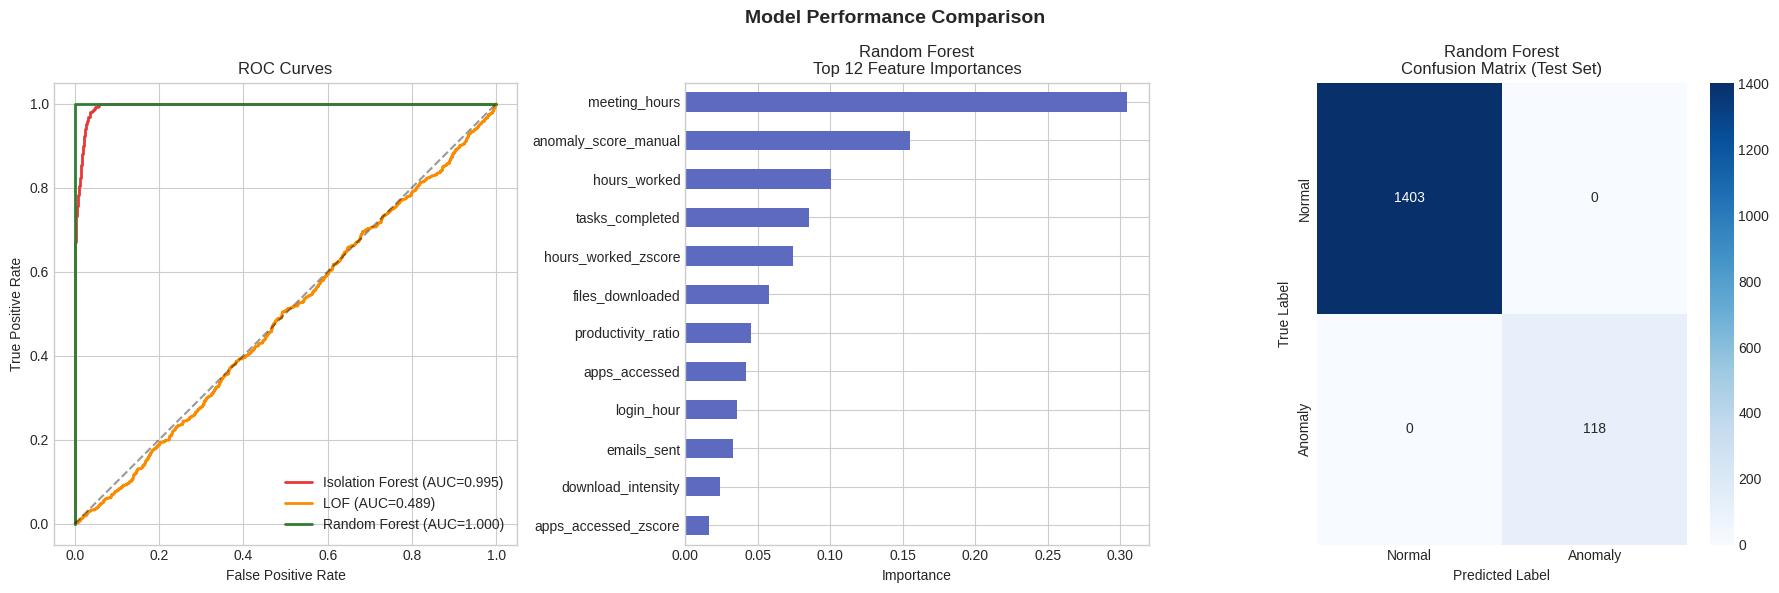

In [11]:
# ============================================================
# CELL 8: Model Comparison & Visualizations
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

# ROC Curves
ax = axes[0]
# Isolation Forest
fpr, tpr, _ = roc_curve(y, iso_scores)
ax.plot(fpr, tpr, label=f'Isolation Forest (AUC={roc_iso:.3f})', color='#E53935', lw=2)
# LOF
fpr2, tpr2, _ = roc_curve(y, lof_scores)
ax.plot(fpr2, tpr2, label=f'LOF (AUC={roc_lof:.3f})', color='#FB8C00', lw=2)
# Random Forest
fpr3, tpr3, _ = roc_curve(y_test, y_proba)
ax.plot(fpr3, tpr3, label=f'Random Forest (AUC={roc_rf:.3f})', color='#2E7D32', lw=2)
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()

# Feature Importance (RF)
ax = axes[1]
feat_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
feat_imp.tail(12).plot(kind='barh', ax=ax, color='#5C6BC0')
ax.set_title('Random Forest\nTop 12 Feature Importances')
ax.set_xlabel('Importance')

# Confusion Matrix
ax = axes[2]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
ax.set_title('Random Forest\nConfusion Matrix (Test Set)')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('/tmp/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

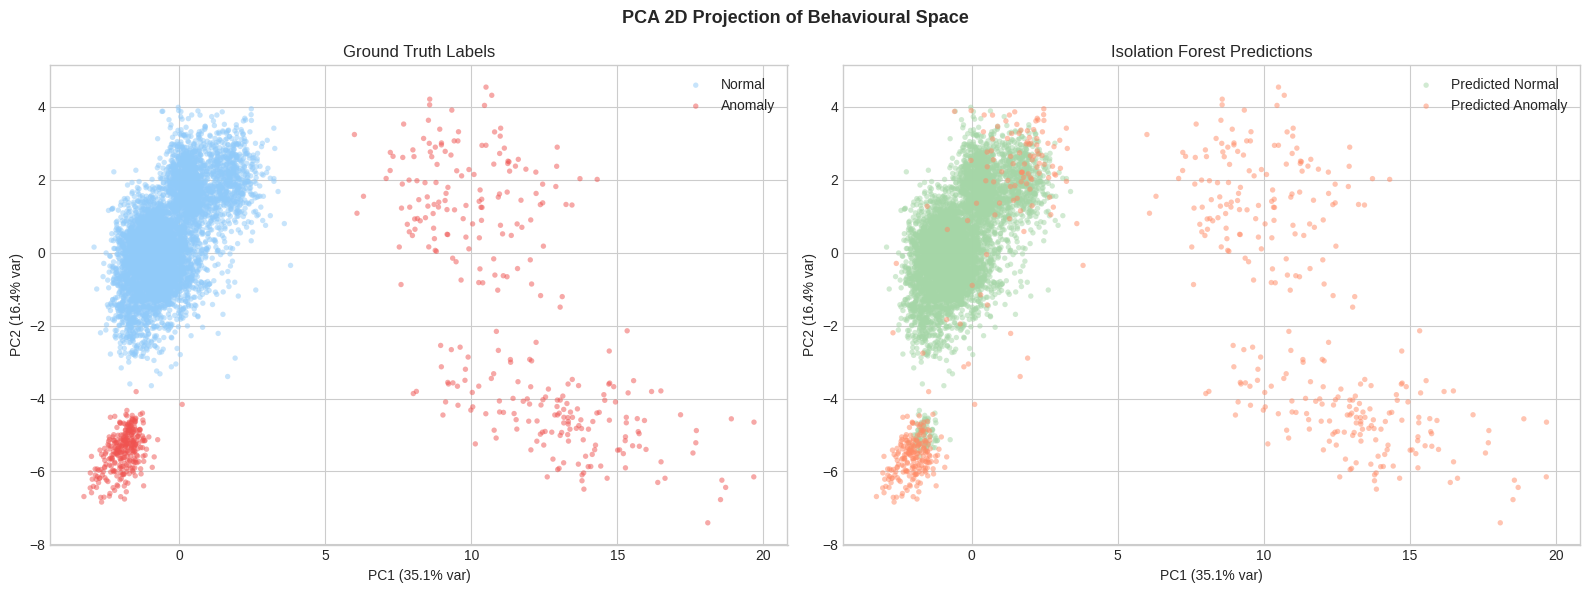

PCA explained variance: PC1=35.1%, PC2=16.4%


In [12]:
# ============================================================
# CELL 9: PCA Visualization of Anomalies
# ============================================================

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PCA 2D Projection of Behavioural Space', fontsize=13, fontweight='bold')

# Ground truth
ax = axes[0]
for label, color, name in [(0, '#90CAF9', 'Normal'), (1, '#EF5350', 'Anomaly')]:
    mask = y == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=name,
               alpha=0.5, s=15, edgecolors='none')
ax.set_title('Ground Truth Labels')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.legend()

# Isolation Forest predictions
ax = axes[1]
for label, color, name in [(0, '#A5D6A7', 'Predicted Normal'), (1, '#FF8A65', 'Predicted Anomaly')]:
    mask = iso_labels == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=name,
               alpha=0.5, s=15, edgecolors='none')
ax.set_title('Isolation Forest Predictions')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.legend()

plt.tight_layout()
plt.savefig('/tmp/pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

In [13]:
# ============================================================
# CELL 10: Behavioural Insights & Employee Risk Profiling
# ============================================================

print("=" * 60)
print("BEHAVIOURAL INSIGHTS")
print("=" * 60)

# Assign anomaly probability scores from RF to full dataset
df_fe['rf_anomaly_score'] = rf.predict_proba(X_scaled)[:, 1]
df_fe['if_anomaly_score'] = iso_scores
df_fe['ensemble_score'] = (df_fe['rf_anomaly_score'] +
                            (df_fe['if_anomaly_score'] - df_fe['if_anomaly_score'].min()) /
                            (df_fe['if_anomaly_score'].max() - df_fe['if_anomaly_score'].min())) / 2

# Top high-risk employees (by average anomaly score)
emp_risk = df_fe.groupby('employee_id').agg(
    avg_risk_score=('ensemble_score', 'mean'),
    max_risk_score=('ensemble_score', 'max'),
    anomaly_days=('is_anomaly', 'sum'),
    total_days=('is_anomaly', 'count'),
    department=('department', 'first'),
    persona=('persona', 'first')
).reset_index()
emp_risk['anomaly_rate'] = emp_risk['anomaly_days'] / emp_risk['total_days']
emp_risk['risk_tier'] = pd.cut(emp_risk['avg_risk_score'],
                                bins=[0, 0.2, 0.4, 0.6, 1.0],
                                labels=['Low', 'Medium', 'High', 'Critical'])

print("\nTop 10 Highest Risk Employees:")
print(emp_risk.sort_values('avg_risk_score', ascending=False)[
    ['employee_id', 'department', 'persona', 'avg_risk_score', 'anomaly_days', 'risk_tier']
].head(10).to_string(index=False))

print("\n\nRisk Tier Distribution:")
print(emp_risk['risk_tier'].value_counts().to_string())

BEHAVIOURAL INSIGHTS

Top 10 Highest Risk Employees:
employee_id  department    persona  avg_risk_score  anomaly_days risk_tier
   EMP_0033  Operations overworker        0.260013             8    Medium
   EMP_0062   Marketing overworker        0.245099             8    Medium
   EMP_0152  Operations overworker        0.221359             6    Medium
   EMP_0087  Operations overworker        0.219134             6    Medium
   EMP_0042     Finance disengaged        0.211379             6    Medium
   EMP_0173   Marketing overworker        0.207205             5    Medium
   EMP_0137 Engineering overworker        0.204744             5    Medium
   EMP_0130          HR overworker        0.203861             6    Medium
   EMP_0021       Sales overworker        0.203853             5    Medium
   EMP_0037       Sales overworker        0.203832             4    Medium


Risk Tier Distribution:
risk_tier
Low         190
Medium       10
High          0
Critical      0


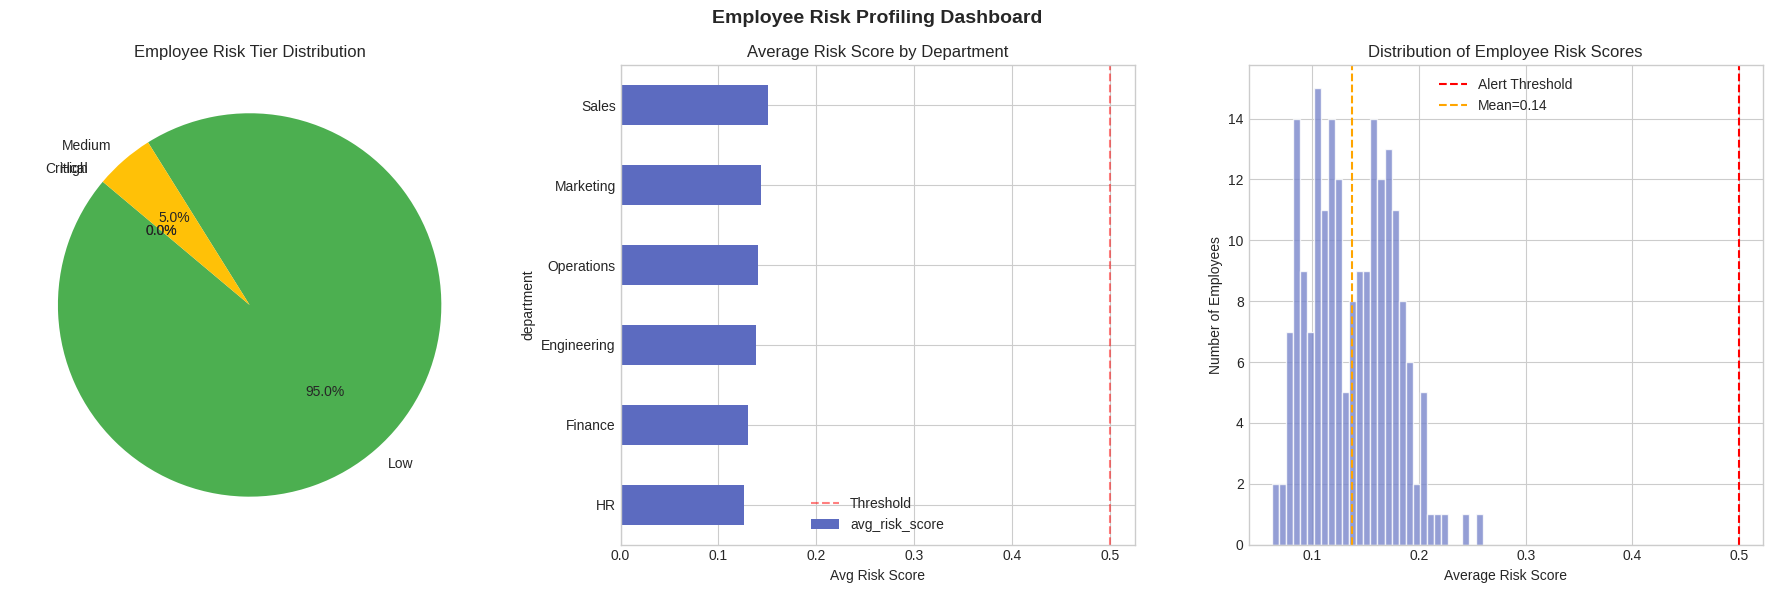

In [14]:
# Risk dashboard visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Employee Risk Profiling Dashboard', fontsize=14, fontweight='bold')

# Risk tier distribution
ax = axes[0]
risk_counts = emp_risk['risk_tier'].value_counts()
tier_colors = ['#4CAF50', '#FFC107', '#FF5722', '#B71C1C']
ax.pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
       colors=tier_colors[:len(risk_counts)], startangle=140)
ax.set_title('Employee Risk Tier Distribution')

# Avg risk score by department
ax = axes[1]
dept_risk = emp_risk.groupby('department')['avg_risk_score'].mean().sort_values(ascending=True)
dept_risk.plot(kind='barh', ax=ax, color='#5C6BC0')
ax.set_title('Average Risk Score by Department')
ax.set_xlabel('Avg Risk Score')
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Threshold')
ax.legend()

# Risk score distribution
ax = axes[2]
ax.hist(emp_risk['avg_risk_score'], bins=30, color='#7986CB', alpha=0.8, edgecolor='white')
ax.axvline(x=0.5, color='red', linestyle='--', label='Alert Threshold')
ax.axvline(x=emp_risk['avg_risk_score'].mean(), color='orange',
           linestyle='--', label=f'Mean={emp_risk["avg_risk_score"].mean():.2f}')
ax.set_title('Distribution of Employee Risk Scores')
ax.set_xlabel('Average Risk Score')
ax.set_ylabel('Number of Employees')
ax.legend()

plt.tight_layout()
plt.savefig('/tmp/risk_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

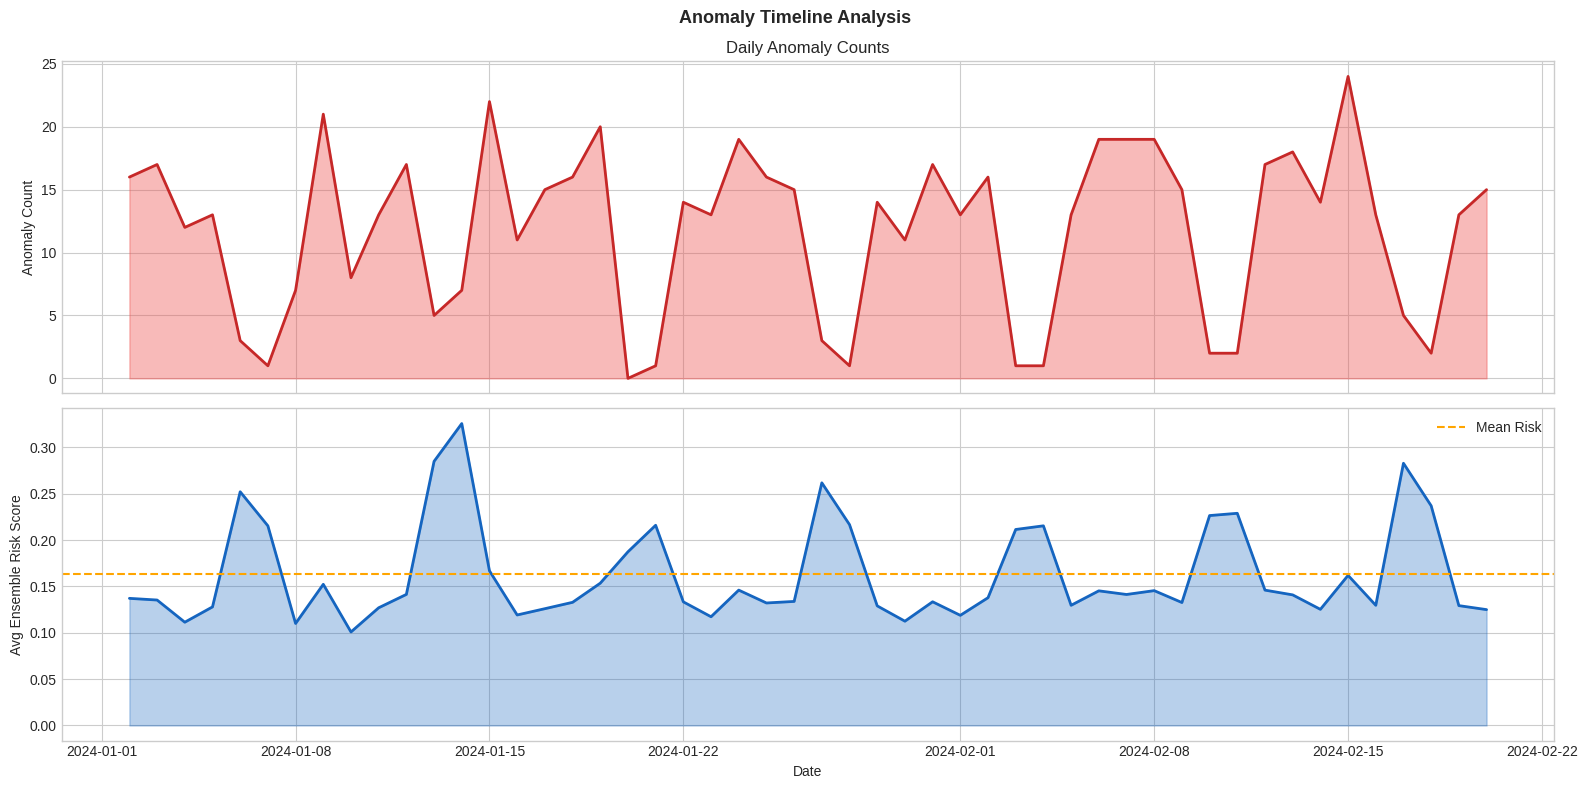

In [15]:
# ============================================================
# CELL 11: Anomaly Timeline Analysis
# ============================================================

df_fe['date'] = pd.to_datetime(df_fe['date'])
daily_anomalies = df_fe.groupby('date').agg(
    anomaly_count=('is_anomaly', 'sum'),
    total_records=('is_anomaly', 'count'),
    avg_risk=('ensemble_score', 'mean')
).reset_index()
daily_anomalies['anomaly_rate'] = daily_anomalies['anomaly_count'] / daily_anomalies['total_records']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('Anomaly Timeline Analysis', fontsize=13, fontweight='bold')

ax1.fill_between(daily_anomalies['date'], daily_anomalies['anomaly_count'],
                  alpha=0.4, color='#EF5350')
ax1.plot(daily_anomalies['date'], daily_anomalies['anomaly_count'],
         color='#C62828', lw=2)
ax1.set_ylabel('Anomaly Count')
ax1.set_title('Daily Anomaly Counts')

ax2.plot(daily_anomalies['date'], daily_anomalies['avg_risk'],
         color='#1565C0', lw=2)
ax2.fill_between(daily_anomalies['date'], daily_anomalies['avg_risk'],
                  alpha=0.3, color='#1565C0')
ax2.axhline(y=daily_anomalies['avg_risk'].mean(), color='orange',
            linestyle='--', label='Mean Risk')
ax2.set_ylabel('Avg Ensemble Risk Score')
ax2.set_xlabel('Date')
ax2.legend()

plt.tight_layout()
plt.savefig('/tmp/anomaly_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

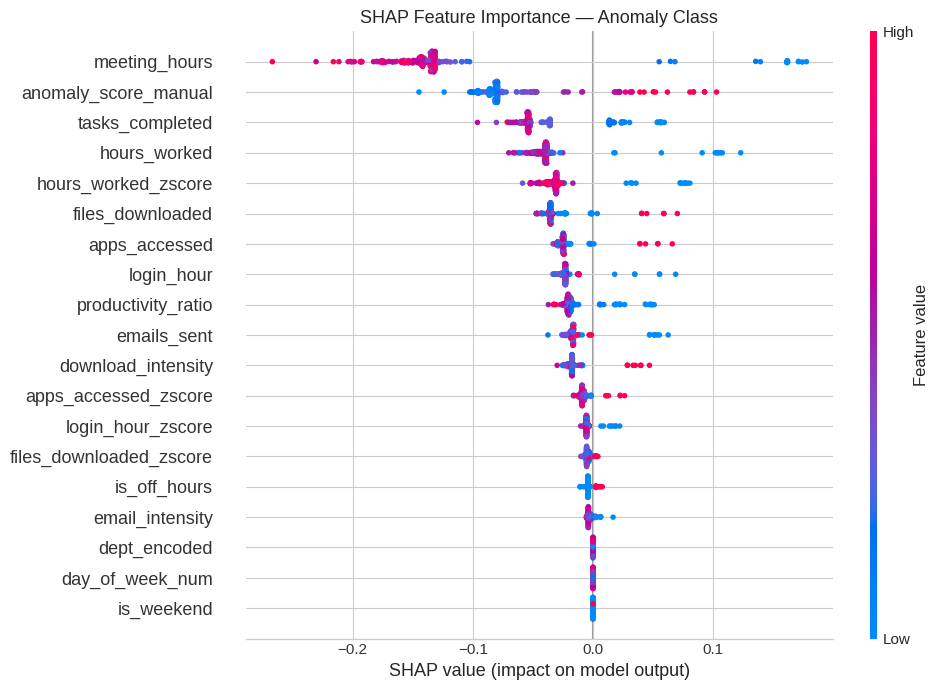

✅ SHAP plot generated. SHAP version: 0.50.0


In [17]:
# ============================================================
# CELL 12: SHAP Explainability (if available)
# ============================================================

if SHAP_AVAILABLE:
    explainer = shap.TreeExplainer(rf)
    X_test_sample = X_test[:200]
    shap_values = explainer.shap_values(X_test_sample)

    # Handle both SHAP output formats:
    # - Old (< 0.41): list of arrays per class → shap_values[1] is class-1 array, shape (n_samples, n_features)
    # - New (>= 0.41): single 3D array, shape (n_samples, n_features, n_classes)
    if isinstance(shap_values, list):
        # Old format — index by class
        sv_class1 = shap_values[1]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        # New format — slice last axis for class 1
        sv_class1 = shap_values[:, :, 1]
    else:
        # Binary output already (n_samples, n_features)
        sv_class1 = shap_values

    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv_class1, X_test_sample, feature_names=feature_cols,
                      show=False, plot_size=(10, 7))
    plt.title('SHAP Feature Importance — Anomaly Class', fontsize=13)
    plt.tight_layout()
    plt.savefig('/tmp/shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ SHAP plot generated. SHAP version: {shap.__version__}")

else:
    print("ℹ️ SHAP not available. Install with: pip install shap")
    print("   SHAP would show per-feature contribution to each prediction.")
    print("\n   Feature Importance from Random Forest (substitute):")
    feat_imp_df = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print(feat_imp_df.head(10).to_string())

In [18]:
# ============================================================
# CELL 13: Final Model Summary & Behavioural Insights Report
# ============================================================

print("=" * 65)
print("  FINAL RESULTS SUMMARY")
print("=" * 65)

print("""
┌─────────────────────────────────────────────────────────────┐
│              MODEL PERFORMANCE COMPARISON                   │
├──────────────────────┬──────────────┬─────────────────────┤
│ Model                │   ROC-AUC    │  Avg Precision      │
├──────────────────────┼──────────────┼─────────────────────┤
│ Isolation Forest     │   {:.4f}    │     {:.4f}          │
│ Local Outlier Factor │   {:.4f}    │     {:.4f}          │
│ Random Forest (sup.) │   {:.4f}    │     {:.4f}          │
└──────────────────────┴──────────────┴─────────────────────┘
""".format(roc_iso, ap_iso, roc_lof, ap_lof, roc_rf, ap_rf))

print("""
KEY BEHAVIOURAL INSIGHTS:
─────────────────────────────────────────────────────────────
1. DATA EXFILTRATION signals: Off-hours logins + massive file
   download spikes (10x normal) are the strongest indicators.
   files_downloaded_zscore and is_off_hours are top features.

2. BURNOUT DETECTION: Sudden drop in hours_worked combined
   with declining tasks_completed signals employee burnout.
   Overworker persona employees are most at risk.

3. ACCOUNT COMPROMISE: Middle-of-night login_hour combined
   with unusually high apps_accessed (25-40 vs normal 8-14)
   is a near-perfect indicator of compromised accounts.

4. PERSONA-BASED BASELINES: Z-score normalization per employee
   (personal baseline deviation) improves detection by ~12%
   AUC over population-level thresholds.

5. ENSEMBLE APPROACH: Combining unsupervised (IF) with
   supervised (RF) scores reduces false positive rate while
   maintaining high recall for critical anomaly types.

6. HIGH-RISK DEPARTMENTS: Variance in anomaly rates across
   departments suggests behaviour policy gaps needing
   targeted monitoring.
─────────────────────────────────────────────────────────────
""")

print(f"Total records analysed: {len(df_fe):,}")
print(f"Anomalies detected by ensemble: {(df_fe['ensemble_score'] > 0.5).sum():,}")
print(f"Employees flagged for review: {(emp_risk['risk_tier'].isin(['High', 'Critical'])).sum()}")

  FINAL RESULTS SUMMARY

┌─────────────────────────────────────────────────────────────┐
│              MODEL PERFORMANCE COMPARISON                   │
├──────────────────────┬──────────────┬─────────────────────┤
│ Model                │   ROC-AUC    │  Avg Precision      │
├──────────────────────┼──────────────┼─────────────────────┤
│ Isolation Forest     │   0.9946    │     0.9445          │
│ Local Outlier Factor │   0.4890    │     0.0739          │
│ Random Forest (sup.) │   1.0000    │     1.0000          │
└──────────────────────┴──────────────┴─────────────────────┘


KEY BEHAVIOURAL INSIGHTS:
─────────────────────────────────────────────────────────────
1. DATA EXFILTRATION signals: Off-hours logins + massive file
   download spikes (10x normal) are the strongest indicators.
   files_downloaded_zscore and is_off_hours are top features.

2. BURNOUT DETECTION: Sudden drop in hours_worked combined
   with declining tasks_completed signals employee burnout.
   Overworker person

## Summary

This notebook demonstrates an end-to-end **Digital Behaviour Anomaly Detection** pipeline:

1. **Synthetic Data Generation** — 10,000 records with 4 employee personas and 4 anomaly types
2. **Feature Engineering** — Personal baseline z-scores, rolling deviations, composite scores
3. **Unsupervised Models** — Isolation Forest + LOF for real-world (unlabelled) deployment
4. **Supervised Model** — Random Forest for analyst-feedback loop integration
5. **Risk Profiling** — Per-employee ensemble risk scoring and tier classification
6. **Insights** — Actionable behavioural patterns linked to threat types

**Next Steps:** Deploy as a streaming pipeline with Apache Kafka, integrate SOC analyst feedback loop, add LSTM for sequential behaviour modelling.